In [1]:
from leagueScripts import NBALeague

league_object = NBALeague.get_cached_league_object()

In [2]:
league_object.get_league_pace_info()

,TEAM_ID,POSS,MIN,PACE
0,1610612737,8339,3971.0,100.798791
1,1610612738,8090,3966.0,97.912254
2,1610612751,8050,3961.0,97.551123
3,1610612766,8048,3946.0,97.897618
4,1610612741,8078,3996.0,97.033033
5,1610612739,8053,3961.0,97.587478
6,1610612742,8263,3941.0,100.640447
7,1610612743,7996,3941.0,97.388480
8,1610612765,8269,3951.0,100.458618
9,1610612744,8261,3966.0,99.981846


In [3]:
league_object.playtype.transition

1.1363811398254322

In [4]:
from leagueScripts import PlayTypeLeagueAverage

assert league_object.playtype.transition == PlayTypeLeagueAverage('offensive', 'team').transition

In [5]:
from nba_api.stats.library.parameters import PlayType
from nba_api.stats.endpoints import SynergyPlayTypes
import pandas as pd

# df = pd.DataFrame(columns=SynergyPlayTypes.expected_data["SynergyPlayType"])
playtypes_df = []
for playtype in PlayTypeLeagueAverage.get_playtype_classes_names():
    _playtype_df = SynergyPlayTypes(play_type_nullable=getattr(PlayType, playtype), type_grouping_nullable='offensive', player_or_team_abbreviation='P').synergy_play_type.get_data_frame()
    playtypes_df.append(_playtype_df)
df = pd.concat(playtypes_df)
df = df[['PLAYER_NAME', 'TEAM_NAME', 'PLAY_TYPE', 'PTS', 'POSS']]

# Define a custom aggregation function
def custom_agg(group):
    # Example: Sum the 'POSS' and take the max of 'PERCENTILE'
    aggregation = {
        'TEAM_NAME': lambda x: ', '.join(x.unique()),  # Combine team names
        'PTS': 'sum',  # Example custom aggregation: take the max percentile
        'POSS': 'sum'  # Example custom aggregation: sum the possessions
    }
    return group.agg(aggregation)

# Apply the custom aggregation for players with multiple teams
df = df.groupby(['PLAYER_NAME', 'PLAY_TYPE']).apply(custom_agg, include_groups=False)
df['PPP'] = df['PTS'] / df['POSS']
# Calculate percentiles
df['PERCENTILE_POSS'] = df.groupby('PLAY_TYPE')['POSS'].rank(pct=True) * 100
df['PERCENTILE_PPP'] = df.groupby('PLAY_TYPE')['PPP'].rank(pct=True) * 100

df

TEAM_NAME  PTS  POSS       PPP  \
PLAYER_NAME     PLAY_TYPE                                                  
AJ Green        Handoff             Milwaukee Bucks   33    23  1.434783   
                OffScreen           Milwaukee Bucks   19    20  0.950000   
                PRBallHandler       Milwaukee Bucks    9    14  0.642857   
                PRRollMan           Milwaukee Bucks   17    14  1.214286   
                Spotup              Milwaukee Bucks  111    90  1.233333   
...                                             ...  ...   ...       ...   
Zion Williamson PRBallHandler  New Orleans Pelicans  249   264  0.943182   
                PRRollMan      New Orleans Pelicans   22    24  0.916667   
                Postup         New Orleans Pelicans  168   188  0.893617   
                Spotup         New Orleans Pelicans   89    91  0.978022   
                Transition     New Orleans Pelicans  282   204  1.382353   

                               PERCENTILE_POSS  PERCENTILE_PPP  
PLAYER_NAME     PLAY_TYPE                                       
AJ Green        Handoff              34.082397       98.876404  
                OffScreen            31.250000       41.666667  
                PRBallHandler         7.243816       15.194346  
                PRRollMan            16.875000       63.750000  
                Spotup               34.560907       90.934844  
...                                        ...             ...  
Zion Williamson PRBallHandler        79.858657       72.084806  
                PRRollMan            42.291667       22.500000  
                Postup               90.277778       28.472222  
                Spotup               35.269122       35.977337  
                Transition           86.764706       92.352941  

[2929 rows x 6 columns]

In [6]:
# Pivot the dataframe
df_pivot = df.pivot_table(index=['PLAYER_NAME'], 
                          columns='PLAY_TYPE', 
                          values=['PERCENTILE_PPP', 'PERCENTILE_POSS'], 
                          aggfunc='first', 
                          fill_value=0)

# Flatten the columns
# df_pivot.columns = [f'{i}_{j}' for i, j in df_pivot.columns]
df_pivot = df_pivot.rename(columns={'PLAYER_NAME_': 'PLAYER_NAME', 'TEAM_NAME_': 'TEAM_NAME'})

df_for_plot = df_pivot['PERCENTILE_PPP'].reset_index()
metrics = df_for_plot.columns[1:].tolist()

In [7]:
df_for_plot

PLAY_TYPE,PLAYER_NAME,Cut,Handoff,Isolation,Misc,OffRebound,OffScreen,PRBallHandler,PRRollMan,Postup,Spotup,Transition
0,AJ Green,0.000000,98.876404,0.000000,0.000000,0.000000,41.666667,15.194346,63.750000,0.000000,90.934844,0.000000
1,Aaron Gordon,89.679715,29.400749,13.675214,46.623794,0.000000,0.000000,11.837456,80.416667,65.277778,59.065156,38.235294
2,Aaron Holiday,0.000000,32.958801,72.222222,0.000000,15.845070,33.593750,88.339223,0.000000,0.000000,74.220963,27.647059
3,Aaron Nesmith,20.284698,91.011236,0.000000,49.517685,81.690141,85.677083,0.000000,92.708333,0.000000,79.886686,81.764706
4,Aaron Wiggins,43.772242,77.153558,0.000000,41.961415,39.964789,0.000000,91.519435,92.708333,0.000000,92.351275,52.352941
...,...,...,...,...,...,...,...,...,...,...,...,...
430,Zach Collins,58.007117,0.000000,76.495726,11.254019,32.570423,0.000000,0.000000,29.166667,49.305556,22.662890,35.294118
431,Zach LaVine,0.000000,79.400749,34.829060,91.961415,0.000000,28.385417,71.731449,0.000000,0.000000,48.725212,67.647059
432,Zavier Simpson,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,16.961131,0.000000,0.000000,0.000000,6.470588
433,Ziaire Williams,42.704626,34.082397,0.000000,54.019293,86.971831,88.541667,5.477032,0.000000,0.000000,0.000000,12.205882


In [8]:
import matplotlib.pyplot as plt
import numpy as np


def plot_radar_chart(data, key_category, metrics, title):
    N = len(metrics)
    theta = np.linspace(0, 2 * np.pi, N, endpoint=False)
    theta = np.concatenate([theta, [theta[0]]])
    
    fig, ax = plt.subplots(figsize=(12, 12), subplot_kw={'projection': 'polar'})
    
    ax.set_title(title, y=1.15, fontsize=20)
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_rlabel_position(90)
    ax.spines['polar'].set_zorder(1)
    ax.spines['polar'].set_color('lightgrey')
    
    color_palette = ['#339F00', '#0500FF', '#9CDADB', '#FF00DE', '#FF9900', '#FFFFFF']
        
    for idx, (i, row) in enumerate(data.iterrows()):
        values = row[metrics].values.flatten().tolist()
        values = values + [values[0]]
        ax.plot(theta, values, linewidth=1.75, linestyle='solid', label=row[key_category], marker='o', markersize=10, color=color_palette[idx % len(color_palette)])
        ax.fill(theta, values, alpha=0.50, color=color_palette[idx % len(color_palette)])
    
    plt.yticks([0, 25, 50, 75, 100], ["0", "25", "50", "75", "100"], color="black", size=12)
    plt.xticks(theta, metrics + [metrics[0]], color='black', size=12)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1)) 
    
    return fig

In [9]:
league_object.players_on_teams_objects_list[0].stats_df['PTS'].sum().item()

841

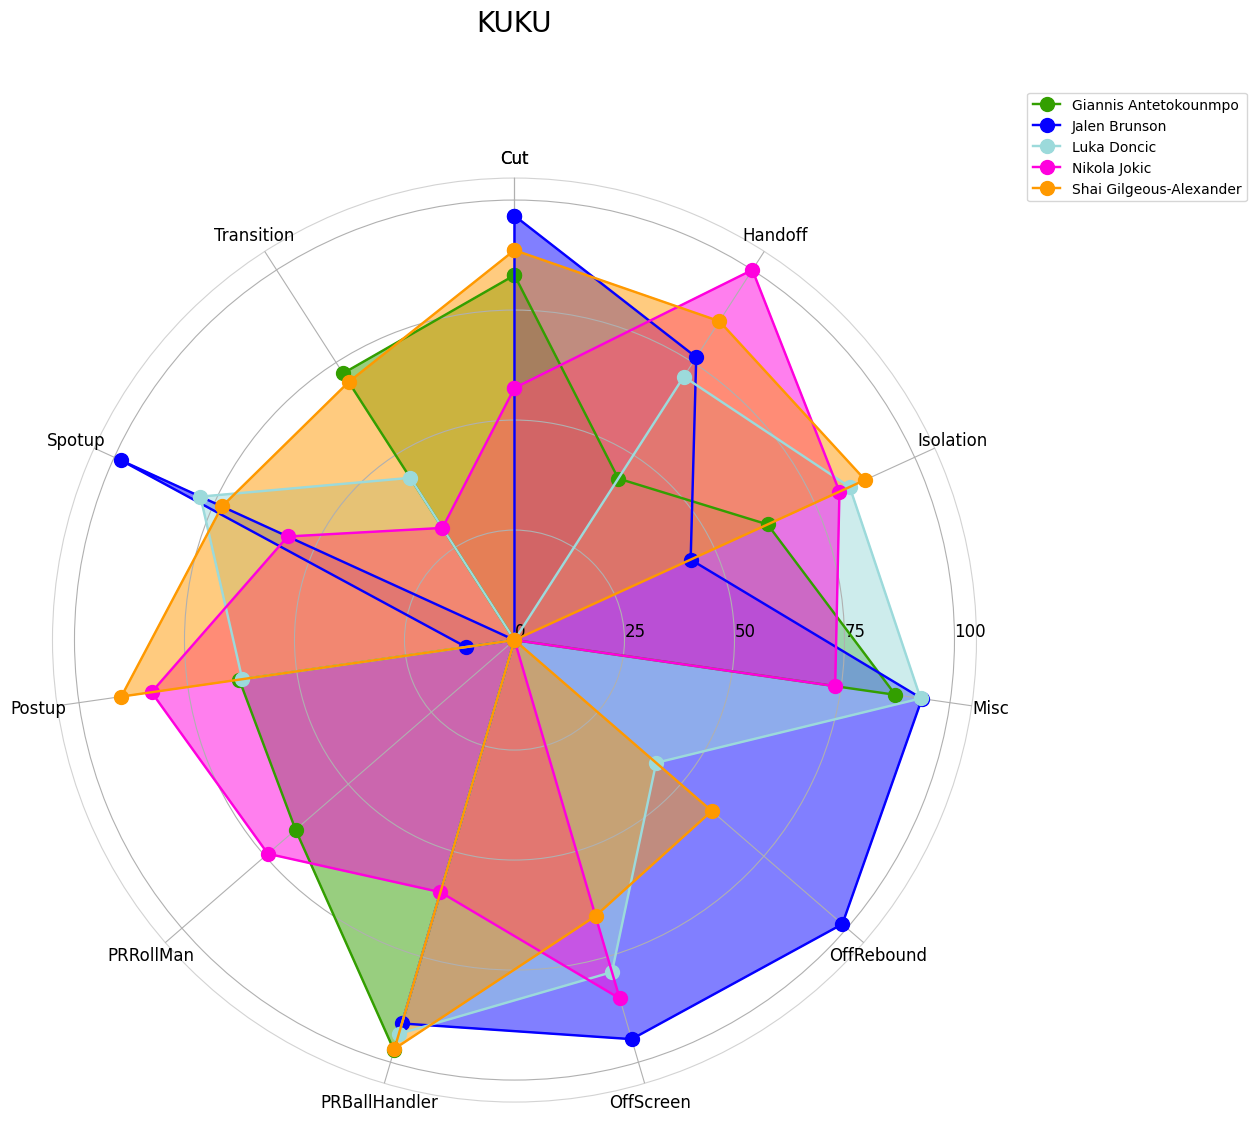

In [10]:
top_scorers = sorted(league_object.players_on_teams_objects_list, key=lambda x: x.stats_df['PTS'].sum().item() if not x.stats_df.empty else 0, reverse=True)[:5]
players_to_plot = [player.player_info['DISPLAY_FIRST_LAST'].item() for player in top_scorers]
# Plot 
fig = plot_radar_chart(df_for_plot[df_for_plot['PLAYER_NAME'].isin(players_to_plot)], 'PLAYER_NAME', metrics, title="KUKU")
plt.show()